# M06-2 Level 1 (Score-Only): Boundary vs Random + Stronger Structural Features

Focus:
- Compare **true boundaries** vs **random beats** on each **single feature**
- PCA / UMAP 2D visualization for separability

Added stronger structural features (score-only):
- Pitch/duration dispersion (std)
- Pitch-class distribution entropy/concentration/variety
- Pitch-class similarity across adjacent beats
- Window-level symmetry in pitch-class patterns
- Deviation from local rolling mean (pitch/density)


In [9]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().parents[1]
mirex_root = repo_root / 'MERIX SUBMISSION' / 'MIREX_Model'
npz_dir = mirex_root / 'beat_data_mazurka_performer_levels'
beat_time_csv = repo_root / 'MazurkaBL-master' / 'beat_time' / 'M06-2beat_time.csv'

level = 1
rng = np.random.default_rng(0)
sym_w = 4
dev_w = 8

sys.path.append(str(mirex_root))
from build_mazurka_beat_npz_performer_levels import build_score_beat_features


In [10]:
# Beat -> measure position mapping (score-only metadata from beat_time)
df_bt = pd.read_csv(beat_time_csv)
measure_num = df_bt['measure_number'].to_numpy()
beat_num = df_bt['beat_number'].to_numpy()

# Compute measure length per beat index
measure_len = np.zeros_like(beat_num, dtype=float)
for m in np.unique(measure_num):
    idx = np.where(measure_num == m)[0]
    if len(idx) == 0:
        continue
    max_beat = beat_num[idx].max()
    m_len = float(max_beat + 1) if max_beat >= 0 else 1.0
    measure_len[idx] = m_len

beat_pos_norm = np.where(measure_len > 0, beat_num / measure_len, 0.0)
print('num_beats (beat_time):', len(beat_pos_norm))


num_beats (beat_time): 288


In [11]:
# Load all Level-1 npz files for M06-2 (all performers)
npz_files = sorted(npz_dir.glob('M06-2_*_L1.npz'))
if not npz_files:
    raise FileNotFoundError(f'No Level-1 npz files found in {npz_dir}')

perfs = {}
for p in npz_files:
    data = np.load(p)
    perf_id = str(data['performer_id'])
    note_feats = data['note_feats'].astype(np.float32)
    beat_ids = data['beat_ids'].astype(np.int32)
    num_beats = int(data['num_beats'])
    boundary = data['boundary_probs'].astype(float)
    b_idx = np.where(boundary > 0)[0]

    # Aggregate score-only beat features (base 6)
    beat_feats = build_score_beat_features(note_feats, beat_ids, num_beats)

    # Load upper-level boundaries for alignment
    l2_path = Path(str(p).replace('_L1.npz', '_L2.npz'))
    l3_path = Path(str(p).replace('_L1.npz', '_L3.npz'))
    b2 = np.where(np.load(l2_path)['boundary_probs'] > 0)[0] if l2_path.exists() else np.array([], dtype=int)
    b3 = np.where(np.load(l3_path)['boundary_probs'] > 0)[0] if l3_path.exists() else np.array([], dtype=int)

    # Build advanced beat-level stats from note_feats
    # note_feats columns: pitch_midi, duration, position, part_idx, is_accent, is_staccato
    pitches = note_feats[:, 0]
    durations = note_feats[:, 1]

    pc_hist = np.zeros((num_beats, 12), dtype=float)
    pitch_mean = np.zeros(num_beats, dtype=float)
    pitch_std = np.zeros(num_beats, dtype=float)
    dur_mean = np.zeros(num_beats, dtype=float)
    dur_std = np.zeros(num_beats, dtype=float)

    for b in range(num_beats):
        idx = np.where(beat_ids == b)[0]
        if len(idx) == 0:
            pitch_mean[b] = np.nan
            pitch_std[b] = np.nan
            dur_mean[b] = np.nan
            dur_std[b] = np.nan
            continue
        ps = pitches[idx]
        ds = durations[idx]
        pitch_mean[b] = np.mean(ps)
        pitch_std[b] = np.std(ps)
        dur_mean[b] = np.mean(ds)
        dur_std[b] = np.std(ds)
        pcs = (ps.astype(int) % 12)
        for c in pcs:
            pc_hist[b, c] += 1
        if pc_hist[b].sum() > 0:
            pc_hist[b] /= pc_hist[b].sum()

    # Pitch-class stats
    pc_entropy = -np.nansum(pc_hist * np.log(pc_hist + 1e-8), axis=1)
    pc_max = np.nanmax(pc_hist, axis=1)
    pc_unique_ratio = np.sum(pc_hist > 0, axis=1) / 12.0

    # Adjacent beat PC similarity
    def cos(a, b, eps=1e-8):
        na = np.linalg.norm(a)
        nb = np.linalg.norm(b)
        if na < eps or nb < eps:
            return np.nan
        return float(np.dot(a, b) / (na * nb))

    pc_cos_prev = np.full(num_beats, np.nan, dtype=float)
    pc_cos_next = np.full(num_beats, np.nan, dtype=float)
    for i in range(num_beats):
        if i - 1 >= 0:
            pc_cos_prev[i] = cos(pc_hist[i], pc_hist[i-1])
        if i + 1 < num_beats:
            pc_cos_next[i] = cos(pc_hist[i], pc_hist[i+1])

    # Window symmetry (pitch-class)
    pc_window_sym = np.full(num_beats, np.nan, dtype=float)
    for i in range(num_beats):
        if i - sym_w < 0 or i + sym_w >= num_beats:
            continue
        pre = pc_hist[i - sym_w:i].sum(axis=0)
        post = pc_hist[i + 1:i + 1 + sym_w].sum(axis=0)
        pc_window_sym[i] = cos(pre, post)

    # Rolling mean deviation for pitch/density
    def rolling_mean(x, w):
        out = np.full_like(x, np.nan, dtype=float)
        for i in range(len(x)):
            s = max(0, i - w)
            e = min(len(x), i + w + 1)
            out[i] = np.nanmean(x[s:e])
        return out

    pitch_rm = rolling_mean(pitch_mean, dev_w)
    density_rm = rolling_mean(beat_feats[:, 0], dev_w)
    pitch_dev = np.abs(pitch_mean - pitch_rm)
    density_dev = np.abs(beat_feats[:, 0] - density_rm)

    perfs[perf_id] = {
        'beat_feats': beat_feats,
        'boundary_idx': b_idx,
        'b2_idx': b2,
        'b3_idx': b3,
        'num_beats': num_beats,
        'pitch_mean': pitch_mean,
        'pitch_std': pitch_std,
        'dur_mean': dur_mean,
        'dur_std': dur_std,
        'pc_entropy': pc_entropy,
        'pc_max': pc_max,
        'pc_unique_ratio': pc_unique_ratio,
        'pc_cos_prev': pc_cos_prev,
        'pc_cos_next': pc_cos_next,
        'pc_window_sym': pc_window_sym,
        'pitch_dev': pitch_dev,
        'density_dev': density_dev,
    }

print('performers:', len(perfs))
example_perf = next(iter(perfs.keys()))
print('example performer:', example_perf, 'beats:', perfs[example_perf]['num_beats'])

feature_names = [
    'note_count_norm',
    'mean_pitch_norm',
    'pitch_range_norm',
    'mean_duration_norm',
    'accent_ratio',
    'staccato_ratio',
    'seg_len_prev',
    'seg_len_next',
    'beat_pos_in_measure',
    'align_L2',
    'align_L3',
    'contour_delta',
    'density_delta',
    'symmetry_cosine',
    'pitch_std_norm',
    'duration_std_norm',
    'pc_entropy',
    'pc_max',
    'pc_unique_ratio',
    'pc_cos_prev',
    'pc_cos_next',
    'pc_window_sym',
    'pitch_dev',
    'density_dev',
]


performers: 42
example performer: pid1263-02 beats: 288


In [12]:
def compute_segment_lengths(boundary_idx, num_beats):
    boundary_idx = np.sort(boundary_idx)
    if len(boundary_idx) == 0:
        return {}, {}
    prev_len = np.full(num_beats, np.nan, dtype=float)
    next_len = np.full(num_beats, np.nan, dtype=float)
    for i in range(num_beats):
        j = boundary_idx[boundary_idx <= i]
        if len(j) > 0:
            prev_len[i] = i - j[-1]
        k = boundary_idx[boundary_idx >= i]
        if len(k) > 0:
            next_len[i] = k[0] - i
    return prev_len, next_len

def cosine_similarity(a, b, eps=1e-8):
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na < eps or nb < eps:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

def symmetry_feature(beat_feats, i, w):
    if i - w < 0 or i + w >= beat_feats.shape[0]:
        return np.nan
    pre = beat_feats[i - w:i].reshape(-1)
    post = beat_feats[i + 1:i + 1 + w].reshape(-1)
    return cosine_similarity(pre, post)

def compute_features_for_indices(beat_feats, indices, boundary_idx, b2_idx, b3_idx, beat_pos_norm, sym_w, adv):
    num_beats = beat_feats.shape[0]
    prev_len, next_len = compute_segment_lengths(boundary_idx, num_beats)
    mean_pitch = beat_feats[:, 1]
    note_count = beat_feats[:, 0]

    def local_delta(x, i):
        prev = x[i] - x[i-1] if i-1 >= 0 else 0.0
        nxt = x[i+1] - x[i] if i+1 < len(x) else 0.0
        return 0.5 * (abs(prev) + abs(nxt))

    b2_set = set(b2_idx.tolist())
    b3_set = set(b3_idx.tolist())

    rows = []
    for i in indices:
        row = []
        # base 6
        row.extend(beat_feats[i].tolist())
        # segment lengths
        row.append(prev_len[i])
        row.append(next_len[i])
        # position in measure
        row.append(beat_pos_norm[i] if i < len(beat_pos_norm) else np.nan)
        # alignment with upper levels
        row.append(1.0 if i in b2_set else 0.0)
        row.append(1.0 if i in b3_set else 0.0)
        # contour / density change
        row.append(local_delta(mean_pitch, i))
        row.append(local_delta(note_count, i))
        # symmetry on base beat feats
        row.append(symmetry_feature(beat_feats, i, sym_w))
        # advanced structural
        row.append(adv['pitch_std'][i] / 127.0)
        row.append(adv['dur_std'][i] / 8.0)
        row.append(adv['pc_entropy'][i])
        row.append(adv['pc_max'][i])
        row.append(adv['pc_unique_ratio'][i])
        row.append(adv['pc_cos_prev'][i])
        row.append(adv['pc_cos_next'][i])
        row.append(adv['pc_window_sym'][i])
        row.append(adv['pitch_dev'][i])
        row.append(adv['density_dev'][i])
        rows.append(row)
    return np.array(rows, dtype=float)


In [13]:
# Build boundary vs random samples across all performers
all_boundary = []
all_random = []

for perf_id, pack in perfs.items():
    beat_feats = pack['beat_feats']
    b_idx = pack['boundary_idx']
    b2 = pack['b2_idx']
    b3 = pack['b3_idx']
    if len(b_idx) == 0:
        continue

    adv = {
        'pitch_std': pack['pitch_std'],
        'dur_std': pack['dur_std'],
        'pc_entropy': pack['pc_entropy'],
        'pc_max': pack['pc_max'],
        'pc_unique_ratio': pack['pc_unique_ratio'],
        'pc_cos_prev': pack['pc_cos_prev'],
        'pc_cos_next': pack['pc_cos_next'],
        'pc_window_sym': pack['pc_window_sym'],
        'pitch_dev': pack['pitch_dev'],
        'density_dev': pack['density_dev'],
    }

    # Boundary samples
    Xb = compute_features_for_indices(beat_feats, b_idx, b_idx, b2, b3, beat_pos_norm, sym_w, adv)
    all_boundary.append(Xb)

    # Random samples (exclude boundaries)
    all_idx = np.arange(beat_feats.shape[0])
    candidate = np.setdiff1d(all_idx, b_idx, assume_unique=False)
    if len(candidate) < len(b_idx):
        rand_idx = rng.choice(all_idx, size=len(b_idx), replace=True)
    else:
        rand_idx = rng.choice(candidate, size=len(b_idx), replace=False)
    Xr = compute_features_for_indices(beat_feats, rand_idx, b_idx, b2, b3, beat_pos_norm, sym_w, adv)
    all_random.append(Xr)

X_b = np.concatenate(all_boundary, axis=0) if all_boundary else np.zeros((0, len(feature_names)))
X_r = np.concatenate(all_random, axis=0) if all_random else np.zeros((0, len(feature_names)))

print('boundary samples:', X_b.shape, 'random samples:', X_r.shape)


boundary samples: (2054, 24) random samples: (2054, 24)


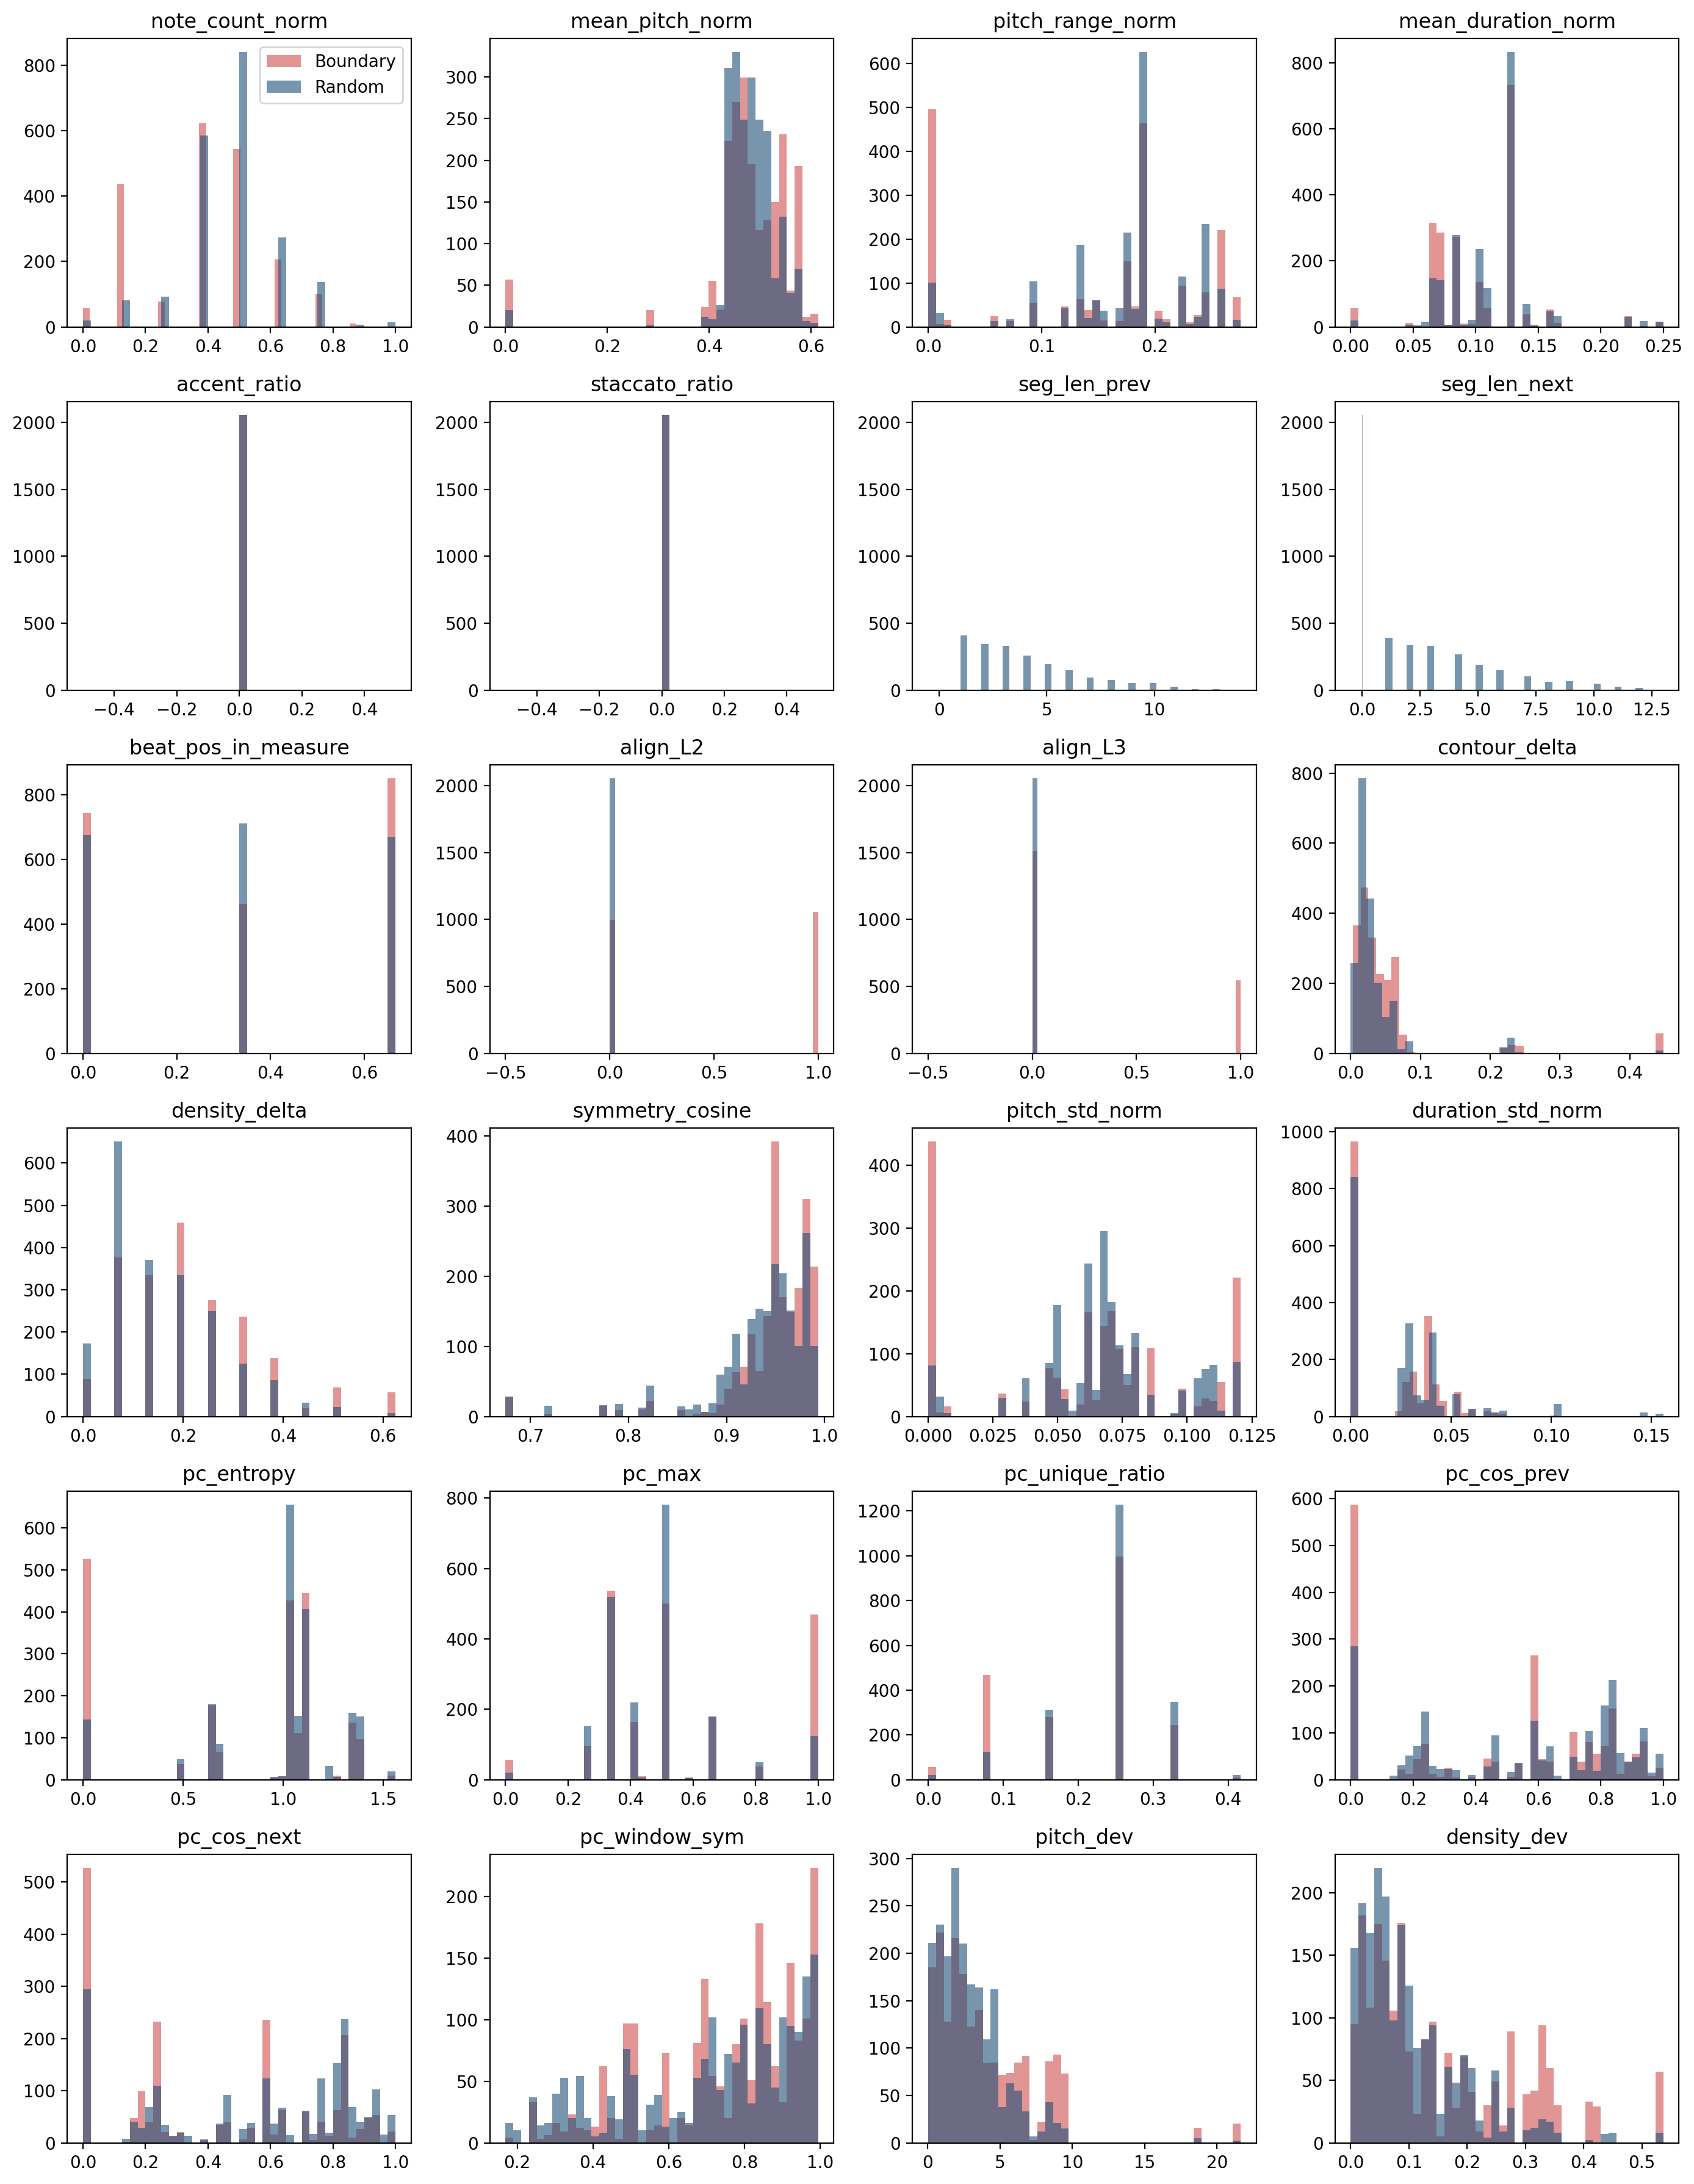

In [14]:
# Single-feature distribution comparisons
n = len(feature_names)
rows = int(np.ceil(n / 4))
plt.figure(figsize=(14, 3 * rows))
for i, name in enumerate(feature_names, 1):
    plt.subplot(rows, 4, i)
    if X_b.shape[0] > 0:
        plt.hist(X_b[:, i-1], bins=40, alpha=0.6, label='Boundary', color='#d04e4e')
    if X_r.shape[0] > 0:
        plt.hist(X_r[:, i-1], bins=40, alpha=0.6, label='Random', color='#1f4e79')
    plt.title(name)
    if i == 1:
        plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# Feature usefulness ranking (univariate)
import numpy as np
from sklearn.metrics import roc_auc_score

def cohens_d(a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    mean_diff = np.mean(a) - np.mean(b)
    s1 = np.var(a, ddof=1)
    s2 = np.var(b, ddof=1)
    pooled = np.sqrt(((len(a)-1)*s1 + (len(b)-1)*s2) / (len(a)+len(b)-2))
    return mean_diff / pooled if pooled > 0 else np.nan

def safe_auc(a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    y = np.array([1]*len(a) + [0]*len(b))
    x = np.concatenate([a, b])
    if np.allclose(x, x[0]):
        return 0.5
    return roc_auc_score(y, x)

try:
    from scipy.stats import ks_2samp
    def ks_stat(a, b):
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]
        if len(a) == 0 or len(b) == 0:
            return np.nan
        return ks_2samp(a, b).statistic
except Exception:
    def ks_stat(a, b):
        return np.nan

rows = []
for i, name in enumerate(feature_names):
    a = X_b[:, i]
    b = X_r[:, i]
    rows.append({
        'feature': name,
        'auc': safe_auc(a, b),
        'cohens_d': cohens_d(a, b),
        'ks_stat': ks_stat(a, b),
        'mean_boundary': np.nanmean(a),
        'mean_random': np.nanmean(b),
    })

rows = sorted(rows, key=lambda r: (abs(r['auc']-0.5) if np.isfinite(r['auc']) else -1, abs(r['cohens_d']) if np.isfinite(r['cohens_d']) else -1), reverse=True)

import pandas as pd
df_rank = pd.DataFrame(rows)
df_rank


,feature,auc,cohens_d,ks_stat,mean_boundary,mean_random
0,seg_len_next,0.000000,-2.116341,1.000000,0.000000,3.916457
1,seg_len_prev,0.000000,-2.072748,1.000000,0.000000,3.882704
2,align_L2,0.756816,1.452957,0.513632,0.513632,0.000000
3,align_L3,0.632181,0.847573,0.264362,0.264362,0.000000
4,note_count_norm,0.372921,-0.500582,0.201558,0.385467,0.471580
5,pc_cos_next,0.378841,-0.442620,0.209038,0.408121,0.554299
6,density_delta,0.619633,0.426294,0.192308,0.206609,0.152964
7,pc_unique_ratio,0.393499,-0.458275,0.185979,0.204236,0.240587
8,density_dev,0.597330,0.443374,0.183057,0.152428,0.102870
9,contour_delta,0.595170,0.246687,0.189873,0.050770,0.034994


In [16]:
# Re-run feature usefulness ranking without leakage features
leakage = {'seg_len_prev', 'seg_len_next', 'align_L2', 'align_L3'}
keep_idx = [i for i, name in enumerate(feature_names) if name not in leakage]
keep_names = [feature_names[i] for i in keep_idx]

Xb_k = X_b[:, keep_idx] if X_b.size else X_b
Xr_k = X_r[:, keep_idx] if X_r.size else X_r

rows = []
for i, name in enumerate(keep_names):
    a = Xb_k[:, i]
    b = Xr_k[:, i]
    rows.append({
        'feature': name,
        'auc': safe_auc(a, b),
        'cohens_d': cohens_d(a, b),
        'ks_stat': ks_stat(a, b),
        'mean_boundary': float(np.nanmean(a)) if a.size else np.nan,
        'mean_random': float(np.nanmean(b)) if b.size else np.nan,
    })

rows = sorted(rows, key=lambda r: (abs(r['auc']-0.5) if np.isfinite(r['auc']) else -1, abs(r['cohens_d']) if np.isfinite(r['cohens_d']) else -1), reverse=True)

df_rank_noleak = pd.DataFrame(rows)
df_rank_noleak


,feature,auc,cohens_d,ks_stat,mean_boundary,mean_random
0,note_count_norm,0.372921,-0.500582,0.201558,0.385467,0.471580
1,pc_cos_next,0.378841,-0.442620,0.209038,0.408121,0.554299
2,density_delta,0.619633,0.426294,0.192308,0.206609,0.152964
3,pc_unique_ratio,0.393499,-0.458275,0.185979,0.204236,0.240587
4,density_dev,0.597330,0.443374,0.183057,0.152428,0.102870
5,contour_delta,0.595170,0.246687,0.189873,0.050770,0.034994
6,symmetry_cosine,0.592436,0.255508,0.171336,0.947465,0.934244
7,pc_entropy,0.414963,-0.481064,0.185979,0.770186,0.973718
8,mean_duration_norm,0.419404,-0.276266,0.165044,0.100128,0.110185
9,pc_cos_prev,0.424744,-0.241646,0.153339,0.458884,0.540725


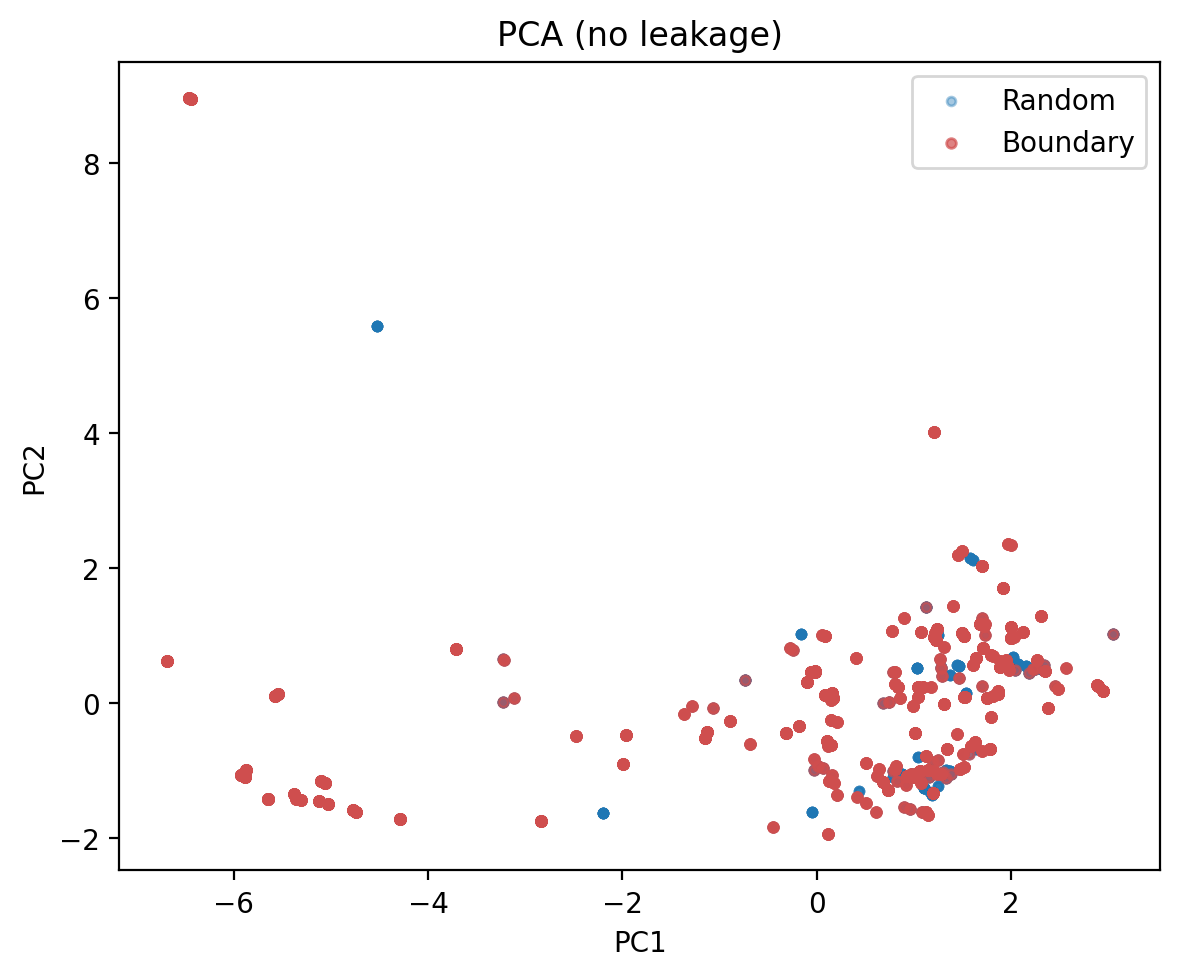

/Users/toddywang/Documents/VsCodeProjects/xmltoexp/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/toddywang/Documents/VsCodeProjects/xmltoexp/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


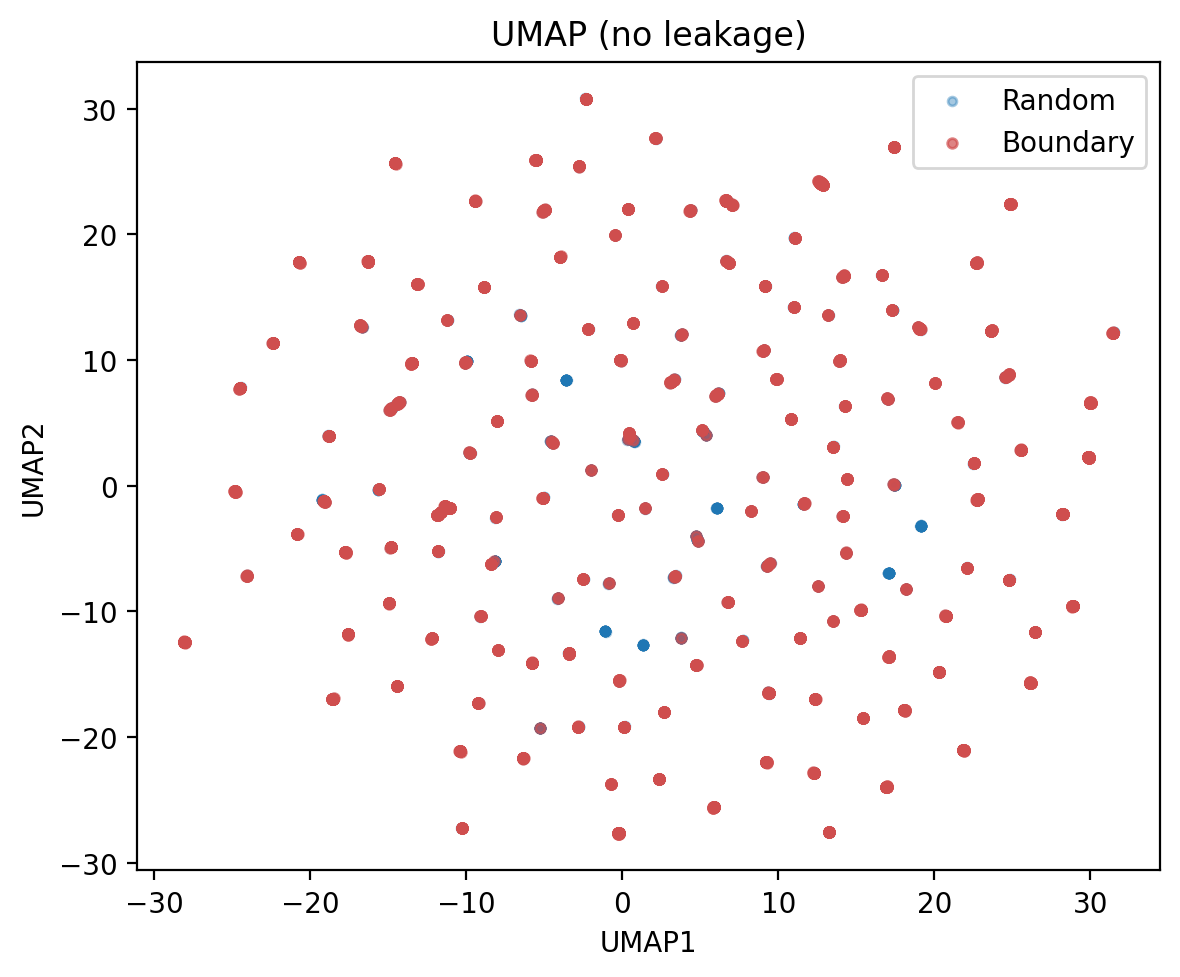

In [17]:
# PCA/UMAP without leakage features
leakage = {'seg_len_prev', 'seg_len_next', 'align_L2', 'align_L3'}
keep_idx = [i for i, name in enumerate(feature_names) if name not in leakage]

Xb_k = X_b[:, keep_idx] if X_b.size else X_b
Xr_k = X_r[:, keep_idx] if X_r.size else X_r

X = np.vstack([Xb_k, Xr_k])
y = np.array([1] * len(Xb_k) + [0] * len(Xr_k))

# Impute NaNs with column means
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Xz = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=0)
xy = pca.fit_transform(Xz)

plt.figure(figsize=(6, 5))
plt.scatter(xy[y==0, 0], xy[y==0, 1], s=10, alpha=0.4, label='Random')
plt.scatter(xy[y==1, 0], xy[y==1, 1], s=12, alpha=0.7, label='Boundary', color='#d04e4e')
plt.title('PCA (no leakage)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

# UMAP (optional)
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=0)
    xy = reducer.fit_transform(Xz)

    plt.figure(figsize=(6, 5))
    plt.scatter(xy[y==0, 0], xy[y==0, 1], s=10, alpha=0.4, label='Random')
    plt.scatter(xy[y==1, 0], xy[y==1, 1], s=12, alpha=0.7, label='Boundary', color='#d04e4e')
    plt.title('UMAP (no leakage)')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('UMAP skipped:', e)


In [18]:
# Lightweight model check: RandomForest (and optional XGBoost)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Use no-leak features by default
leakage = {'seg_len_prev', 'seg_len_next', 'align_L2', 'align_L3'}
keep_idx = [i for i, name in enumerate(feature_names) if name not in leakage]
keep_names = [feature_names[i] for i in keep_idx]

Xb_k = X_b[:, keep_idx] if X_b.size else X_b
Xr_k = X_r[:, keep_idx] if X_r.size else X_r
X = np.vstack([Xb_k, Xr_k])
y = np.array([1] * len(Xb_k) + [0] * len(Xr_k))

# Impute NaNs with column means
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    random_state=0,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print('RandomForest AUC (no-leak):', auc)

# Feature importance
import pandas as pd
imp = pd.DataFrame({
    'feature': keep_names,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False)
imp.head(15)

# Optional: XGBoost if installed
try:
    import xgboost as xgb
    xgb_clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',
        random_state=0,
    )
    xgb_clf.fit(X_train, y_train)
    proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
    auc_xgb = roc_auc_score(y_test, proba_xgb)
    print('XGBoost AUC (no-leak):', auc_xgb)

    imp_xgb = pd.DataFrame({
        'feature': keep_names,
        'importance': xgb_clf.feature_importances_,
    }).sort_values('importance', ascending=False)
    imp_xgb.head(15)
except Exception as e:
    print('XGBoost skipped:', e)


RandomForest AUC (no-leak): 0.8064985055463174
XGBoost AUC (no-leak): 0.8091059062493424


In [ ]:
# Visualize model boundary: 2D projection + predicted probability coloring
# Uses the RandomForest model trained above (rf) and the no-leak feature set.

from sklearn.decomposition import PCA
import numpy as np

# Rebuild no-leak feature matrix (same as RF cell)
leakage = {'seg_len_prev', 'seg_len_next', 'align_L2', 'align_L3'}
keep_idx = [i for i, name in enumerate(feature_names) if name not in leakage]

Xb_k = X_b[:, keep_idx] if X_b.size else X_b
Xr_k = X_r[:, keep_idx] if X_r.size else X_r
X = np.vstack([Xb_k, Xr_k])
y = np.array([1] * len(Xb_k) + [0] * len(Xr_k))

# Impute NaNs with column means
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

# Predicted probability from trained RF
proba_all = rf.predict_proba(X)[:, 1]

# PCA projection for visualization
pca = PCA(n_components=2, random_state=0)
xy = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
sc = plt.scatter(xy[:, 0], xy[:, 1], c=proba_all, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(sc, label='Predicted boundary probability')
plt.title('RF boundary probability over PCA space (no-leak)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# Optional overlay: true labels
plt.figure(figsize=(6, 5))
plt.scatter(xy[y==0, 0], xy[y==0, 1], s=8, alpha=0.3, label='Random')
plt.scatter(xy[y==1, 0], xy[y==1, 1], s=10, alpha=0.8, label='Boundary', color='#d04e4e')
plt.title('True labels over PCA space (no-leak)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Grouped CV by performer (no-leak features)
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

leakage = {'seg_len_prev', 'seg_len_next', 'align_L2', 'align_L3'}
keep_idx = [i for i, name in enumerate(feature_names) if name not in leakage]

X_list = []
y_list = []
groups = []

for perf_id, pack in perfs.items():
    # collect boundary and random samples per performer
    beat_feats = pack['beat_feats']
    b_idx = pack['boundary_idx']
    b2 = pack['b2_idx']
    b3 = pack['b3_idx']
    if len(b_idx) == 0:
        continue

    adv = {
        'pitch_std': pack['pitch_std'],
        'dur_std': pack['dur_std'],
        'pc_entropy': pack['pc_entropy'],
        'pc_max': pack['pc_max'],
        'pc_unique_ratio': pack['pc_unique_ratio'],
        'pc_cos_prev': pack['pc_cos_prev'],
        'pc_cos_next': pack['pc_cos_next'],
        'pc_window_sym': pack['pc_window_sym'],
        'pitch_dev': pack['pitch_dev'],
        'density_dev': pack['density_dev'],
    }

    Xb = compute_features_for_indices(beat_feats, b_idx, b_idx, b2, b3, beat_pos_norm, sym_w, adv)
    # Random samples (exclude boundaries)
    all_idx = np.arange(beat_feats.shape[0])
    candidate = np.setdiff1d(all_idx, b_idx, assume_unique=False)
    if len(candidate) < len(b_idx):
        rand_idx = rng.choice(all_idx, size=len(b_idx), replace=True)
    else:
        rand_idx = rng.choice(candidate, size=len(b_idx), replace=False)
    Xr = compute_features_for_indices(beat_feats, rand_idx, b_idx, b2, b3, beat_pos_norm, sym_w, adv)

    Xb = Xb[:, keep_idx]
    Xr = Xr[:, keep_idx]

    X = np.vstack([Xb, Xr])
    y = np.array([1]*len(Xb) + [0]*len(Xr))

    # Impute NaNs with column means
    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])

    X_list.append(X)
    y_list.append(y)
    groups.append(np.full(len(y), perf_id))

X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)
groups_all = np.concatenate(groups)

gkf = GroupKFold(n_splits=5)
aucs = []
for train_idx, test_idx in gkf.split(X_all, y_all, groups_all):
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        random_state=0,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    proba = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    aucs.append(auc)

print('Grouped CV AUCs:', aucs)
print('Mean AUC:', float(np.mean(aucs)), 'Std:', float(np.std(aucs)))


In [ ]:
# Grouped CV across ALL levels (1..6)
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

leakage = {'seg_len_prev', 'seg_len_next', 'align_L2', 'align_L3'}
keep_idx = [i for i, name in enumerate(feature_names) if name not in leakage]

def load_perfs_for_level(level):
    npz_files = sorted(npz_dir.glob(f'M06-2_*_L{level}.npz'))
    if not npz_files:
        return {}
    perfs = {}
    for p in npz_files:
        data = np.load(p)
        perf_id = str(data['performer_id'])
        note_feats = data['note_feats'].astype(np.float32)
        beat_ids = data['beat_ids'].astype(np.int32)
        num_beats = int(data['num_beats'])
        boundary = data['boundary_probs'].astype(float)
        b_idx = np.where(boundary > 0)[0]

        beat_feats = build_score_beat_features(note_feats, beat_ids, num_beats)

        l2_path = Path(str(p).replace(f'_L{level}.npz', '_L2.npz'))
        l3_path = Path(str(p).replace(f'_L{level}.npz', '_L3.npz'))
        b2 = np.where(np.load(l2_path)['boundary_probs'] > 0)[0] if l2_path.exists() else np.array([], dtype=int)
        b3 = np.where(np.load(l3_path)['boundary_probs'] > 0)[0] if l3_path.exists() else np.array([], dtype=int)

        pitches = note_feats[:, 0]
        durations = note_feats[:, 1]

        pc_hist = np.zeros((num_beats, 12), dtype=float)
        pitch_mean = np.zeros(num_beats, dtype=float)
        pitch_std = np.zeros(num_beats, dtype=float)
        dur_mean = np.zeros(num_beats, dtype=float)
        dur_std = np.zeros(num_beats, dtype=float)

        for b in range(num_beats):
            idx = np.where(beat_ids == b)[0]
            if len(idx) == 0:
                pitch_mean[b] = np.nan
                pitch_std[b] = np.nan
                dur_mean[b] = np.nan
                dur_std[b] = np.nan
                continue
            ps = pitches[idx]
            ds = durations[idx]
            pitch_mean[b] = np.mean(ps)
            pitch_std[b] = np.std(ps)
            dur_mean[b] = np.mean(ds)
            dur_std[b] = np.std(ds)
            pcs = (ps.astype(int) % 12)
            for c in pcs:
                pc_hist[b, c] += 1
            if pc_hist[b].sum() > 0:
                pc_hist[b] /= pc_hist[b].sum()

        pc_entropy = -np.nansum(pc_hist * np.log(pc_hist + 1e-8), axis=1)
        pc_max = np.nanmax(pc_hist, axis=1)
        pc_unique_ratio = np.sum(pc_hist > 0, axis=1) / 12.0

        def cos(a, b, eps=1e-8):
            na = np.linalg.norm(a)
            nb = np.linalg.norm(b)
            if na < eps or nb < eps:
                return np.nan
            return float(np.dot(a, b) / (na * nb))

        pc_cos_prev = np.full(num_beats, np.nan, dtype=float)
        pc_cos_next = np.full(num_beats, np.nan, dtype=float)
        for i in range(num_beats):
            if i - 1 >= 0:
                pc_cos_prev[i] = cos(pc_hist[i], pc_hist[i-1])
            if i + 1 < num_beats:
                pc_cos_next[i] = cos(pc_hist[i], pc_hist[i+1])

        pc_window_sym = np.full(num_beats, np.nan, dtype=float)
        for i in range(num_beats):
            if i - sym_w < 0 or i + sym_w >= num_beats:
                continue
            pre = pc_hist[i - sym_w:i].sum(axis=0)
            post = pc_hist[i + 1:i + 1 + sym_w].sum(axis=0)
            pc_window_sym[i] = cos(pre, post)

        def rolling_mean(x, w):
            out = np.full_like(x, np.nan, dtype=float)
            for i in range(len(x)):
                s = max(0, i - w)
                e = min(len(x), i + w + 1)
                out[i] = np.nanmean(x[s:e])
            return out

        pitch_rm = rolling_mean(pitch_mean, dev_w)
        density_rm = rolling_mean(beat_feats[:, 0], dev_w)
        pitch_dev = np.abs(pitch_mean - pitch_rm)
        density_dev = np.abs(beat_feats[:, 0] - density_rm)

        perfs[perf_id] = {
            'beat_feats': beat_feats,
            'boundary_idx': b_idx,
            'b2_idx': b2,
            'b3_idx': b3,
            'num_beats': num_beats,
            'pitch_std': pitch_std,
            'dur_std': dur_std,
            'pc_entropy': pc_entropy,
            'pc_max': pc_max,
            'pc_unique_ratio': pc_unique_ratio,
            'pc_cos_prev': pc_cos_prev,
            'pc_cos_next': pc_cos_next,
            'pc_window_sym': pc_window_sym,
            'pitch_dev': pitch_dev,
            'density_dev': density_dev,
        }
    return perfs

def grouped_cv_auc(perfs):
    X_list, y_list, groups = [], [], []
    for perf_id, pack in perfs.items():
        beat_feats = pack['beat_feats']
        b_idx = pack['boundary_idx']
        b2 = pack['b2_idx']
        b3 = pack['b3_idx']
        if len(b_idx) == 0:
            continue
        adv = {
            'pitch_std': pack['pitch_std'],
            'dur_std': pack['dur_std'],
            'pc_entropy': pack['pc_entropy'],
            'pc_max': pack['pc_max'],
            'pc_unique_ratio': pack['pc_unique_ratio'],
            'pc_cos_prev': pack['pc_cos_prev'],
            'pc_cos_next': pack['pc_cos_next'],
            'pc_window_sym': pack['pc_window_sym'],
            'pitch_dev': pack['pitch_dev'],
            'density_dev': pack['density_dev'],
        }
        Xb = compute_features_for_indices(beat_feats, b_idx, b_idx, b2, b3, beat_pos_norm, sym_w, adv)
        all_idx = np.arange(beat_feats.shape[0])
        candidate = np.setdiff1d(all_idx, b_idx, assume_unique=False)
        if len(candidate) < len(b_idx):
            rand_idx = rng.choice(all_idx, size=len(b_idx), replace=True)
        else:
            rand_idx = rng.choice(candidate, size=len(b_idx), replace=False)
        Xr = compute_features_for_indices(beat_feats, rand_idx, b_idx, b2, b3, beat_pos_norm, sym_w, adv)

        Xb = Xb[:, keep_idx]
        Xr = Xr[:, keep_idx]

        X = np.vstack([Xb, Xr])
        y = np.array([1]*len(Xb) + [0]*len(Xr))

        col_means = np.nanmean(X, axis=0)
        inds = np.where(np.isnan(X))
        X[inds] = np.take(col_means, inds[1])

        X_list.append(X)
        y_list.append(y)
        groups.append(np.full(len(y), perf_id))

    if not X_list:
        return None
    X_all = np.vstack(X_list)
    y_all = np.concatenate(y_list)
    groups_all = np.concatenate(groups)

    gkf = GroupKFold(n_splits=5)
    aucs = []
    for train_idx, test_idx in gkf.split(X_all, y_all, groups_all):
        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=5,
            random_state=0,
            n_jobs=-1,
        )
        rf.fit(X_train, y_train)
        proba = rf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
        aucs.append(auc)
    return aucs

level_results = {}
for lvl in range(1, 7):
    perfs_lvl = load_perfs_for_level(lvl)
    aucs = grouped_cv_auc(perfs_lvl)
    if aucs is None:
        level_results[lvl] = None
        continue
    level_results[lvl] = {
        'aucs': aucs,
        'mean': float(np.mean(aucs)),
        'std': float(np.std(aucs)),
    }

level_results
